# Analisis Evaluasi Final Top-1 sampai Top-10

Notebook ini membuat artefak analisis utama Bab 6 untuk evaluasi Top-1 sampai Top-10. Data dibaca dari CSV final di `results/final/generation/`. Notebook ini tidak menjalankan ulang preprocessing, chunking, embedding, retrieval, generation, atau model apa pun.


In [1]:
from pathlib import Path
import re
import math
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if not (ROOT / 'results' / 'final' / 'generation').exists():
    ROOT = (Path.cwd() / '..').resolve()
GEN_DIR = ROOT / 'results' / 'final' / 'generation'
GT_DIR = ROOT / 'data' / 'ground_truth'
OUT_DIR = ROOT / 'results' / 'final' / 'analysis10'
FIG_DIR = OUT_DIR / 'figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

TOPK_MIN = 1
TOPK_MAX = 10
METHOD_ORDER = ['Element-Based', 'Max-Min Semantic', 'Recursive']
METHOD_SHORT = {
    'Element-Based': 'Element',
    'Max-Min Semantic': 'MaxMin',
    'MaxMin Semantic': 'MaxMin',
    'Recursive': 'Recursive',
    'element_based': 'Element',
    'maxmin_semantic': 'MaxMin',
    'recursive': 'Recursive',
}
METHOD_DISPLAY = {
    'Element': 'Element-Based',
    'MaxMin': 'Max-Min Semantic',
    'Recursive': 'Recursive',
}
METHOD_TO_SOURCE = {
    'Element': 'Element-Based',
    'MaxMin': 'Max-Min Semantic',
    'Recursive': 'Recursive',
}
METHOD_COLORS = {'Element': '#1f77b4', 'MaxMin': '#ff7f0e', 'Recursive': '#2ca02c'}
METHOD_STYLES = {
    'Element': {'marker': 'o', 'linestyle': '-'},
    'MaxMin': {'marker': 's', 'linestyle': '-'},
    'Recursive': {'marker': '^', 'linestyle': '-'},
}
METRICS = ['precision_at_k', 'recall_at_k', 'mrr', 'f1_at_k', 'bleu', 'rouge_l']
METRIC_LABELS = {
    'precision_at_k': 'Precision@k',
    'recall_at_k': 'Recall@k',
    'mrr': 'MRR',
    'f1_at_k': 'F1@k',
    'bleu': 'BLEU',
    'rouge_l': 'ROUGE-L',
}

def file_for_top_k(k: int) -> Path:
    matches = sorted(GEN_DIR.glob(f'eval_*_top{k}.csv'))
    if not matches:
        raise FileNotFoundError(f'CSV final Top-{k} tidak ditemukan di {GEN_DIR}')
    return matches[-1]

def to_numeric(series):
    return pd.to_numeric(series.replace({'N/A': np.nan, '': np.nan}), errors='coerce')

def compute_f1_from_pr(precision, recall):
    if pd.isna(precision) or pd.isna(recall):
        return np.nan
    denom = precision + recall
    if denom == 0:
        return 0.0
    return (2 * precision * recall) / denom

In [2]:
frames = []
source_files = []
for top_k in range(TOPK_MIN, TOPK_MAX + 1):
    csv_path = file_for_top_k(top_k)
    df = pd.read_csv(csv_path)
    df['top_k'] = top_k
    df['source_file'] = str(csv_path.relative_to(ROOT))
    frames.append(df)
    source_files.append(csv_path.relative_to(ROOT).as_posix())

raw_data = pd.concat(frames, ignore_index=True)
raw_data['method_short'] = raw_data['method'].map(METHOD_SHORT)
if raw_data['method_short'].isna().any():
    unknown = sorted(raw_data.loc[raw_data['method_short'].isna(), 'method'].dropna().unique())
    raise ValueError(f'Method tidak dikenal: {unknown}')

rouge_col = 'rouge_l_recall' if 'rouge_l_recall' in raw_data.columns else 'rouge_l'
required_columns = ['method', 'top_k', 'precision_at_k', 'recall_at_k', 'mrr', 'bleu', rouge_col]
missing_columns = [col for col in required_columns if col not in raw_data.columns]
if missing_columns:
    raise ValueError(f'Kolom wajib tidak ditemukan: {missing_columns}')

for col in ['precision_at_k', 'recall_at_k', 'mrr', 'bleu', rouge_col]:
    raw_data[col] = to_numeric(raw_data[col])
raw_data = raw_data.rename(columns={rouge_col: 'rouge_l'})

metrics_by_k = (
    raw_data
    .groupby(['top_k', 'method_short'], as_index=False)
    .agg(
        method=('method', 'first'),
        row_count=('query_id', 'count'),
        evaluated_retrieval=('mrr', lambda s: int(s.notna().sum())),
        precision_at_k=('precision_at_k', 'mean'),
        recall_at_k=('recall_at_k', 'mean'),
        mrr=('mrr', 'mean'),
        bleu=('bleu', 'mean'),
        rouge_l=('rouge_l', 'mean'),
        missing_precision_at_k=('precision_at_k', lambda s: int(s.isna().sum())),
        missing_recall_at_k=('recall_at_k', lambda s: int(s.isna().sum())),
        missing_mrr=('mrr', lambda s: int(s.isna().sum())),
        missing_bleu=('bleu', lambda s: int(s.isna().sum())),
        missing_rouge_l=('rouge_l', lambda s: int(s.isna().sum())),
    )
)
metrics_by_k['method'] = metrics_by_k['method_short'].map(METHOD_TO_SOURCE)
metrics_by_k['f1_at_k'] = metrics_by_k.apply(
    lambda row: compute_f1_from_pr(row['precision_at_k'], row['recall_at_k']),
    axis=1,
)
metrics_by_k = metrics_by_k[
    ['top_k', 'method', 'method_short', 'row_count', 'evaluated_retrieval',
     'precision_at_k', 'recall_at_k', 'mrr', 'f1_at_k', 'bleu', 'rouge_l',
     'missing_precision_at_k', 'missing_recall_at_k', 'missing_mrr', 'missing_bleu', 'missing_rouge_l']
].sort_values(['top_k', 'method_short']).reset_index(drop=True)

method_summary = (
    metrics_by_k
    .groupby(['method', 'method_short'], as_index=False)[METRICS]
    .mean()
)
method_summary['method_short'] = pd.Categorical(method_summary['method_short'], ['Element', 'MaxMin', 'Recursive'], ordered=True)
method_summary = method_summary.sort_values('method_short').reset_index(drop=True)

winners = []
for metric in METRICS:
    summary_sorted = method_summary.sort_values(metric, ascending=False)
    winning_method = summary_sorted.iloc[0]['method']
    highest_average = summary_sorted.iloc[0][metric]
    per_k_winners = metrics_by_k.loc[metrics_by_k.groupby('top_k')[metric].idxmax()]
    win_counts = per_k_winners['method'].value_counts().to_dict()
    winners.append({
        'metric': metric,
        'metric_label': METRIC_LABELS[metric],
        'winning_method_by_average': winning_method,
        'highest_average': highest_average,
        'topk_win_count_element_based': int(win_counts.get('Element-Based', 0)),
        'topk_win_count_max_min_semantic': int(win_counts.get('Max-Min Semantic', 0)),
        'topk_win_count_recursive': int(win_counts.get('Recursive', 0)),
        'topk_winner_counts': '; '.join([
            f"Element-Based: {int(win_counts.get('Element-Based', 0))}",
            f"Max-Min Semantic: {int(win_counts.get('Max-Min Semantic', 0))}",
            f"Recursive: {int(win_counts.get('Recursive', 0))}",
        ]),
    })
winners_df = pd.DataFrame(winners)

overall_average = method_summary.copy()
overall_average['overall_average'] = overall_average[METRICS].mean(axis=1)

display(metrics_by_k.round(6).head(9))
display(method_summary.round(6))
display(winners_df.round(6))
display(overall_average.round(6))

,top_k,method,method_short,row_count,evaluated_retrieval,precision_at_k,recall_at_k,mrr,f1_at_k,bleu,rouge_l,missing_precision_at_k,missing_recall_at_k,missing_mrr,missing_bleu,missing_rouge_l
0,1,Element-Based,Element,30,28,0.285714,0.199404,0.285714,0.234881,0.154183,0.626993,2,2,2,0,0
1,1,Max-Min Semantic,MaxMin,30,29,0.206897,0.126434,0.206897,0.156954,0.125193,0.601290,1,1,1,0,0
2,1,Recursive,Recursive,30,29,0.344828,0.148848,0.344828,0.207938,0.142553,0.640597,1,1,1,0,0
3,2,Element-Based,Element,30,28,0.178571,0.244046,0.303571,0.206237,0.129923,0.691790,2,2,2,0,0
4,2,Max-Min Semantic,MaxMin,30,29,0.206897,0.267241,0.293103,0.233229,0.122383,0.623723,1,1,1,0,0
5,2,Recursive,Recursive,30,29,0.275862,0.260345,0.396552,0.267879,0.142047,0.673467,1,1,1,0,0
6,3,Element-Based,Element,30,28,0.142846,0.297618,0.327379,0.193040,0.110457,0.675373,2,2,2,0,0
7,3,Max-Min Semantic,MaxMin,30,29,0.160907,0.318966,0.316090,0.213906,0.119797,0.657727,1,1,1,0,0
8,3,Recursive,Recursive,30,29,0.183900,0.260345,0.396552,0.215545,0.144797,0.701823,1,1,1,0,0


,method,method_short,precision_at_k,recall_at_k,mrr,f1_at_k,bleu,rouge_l
0,Element-Based,Element,0.141642,0.399285,0.348571,0.191202,0.118854,0.683187
1,Max-Min Semantic,MaxMin,0.134217,0.412011,0.329098,0.183994,0.116745,0.646362
2,Recursive,Recursive,0.169323,0.346494,0.419369,0.202140,0.140455,0.678738


,metric,metric_label,winning_method_by_average,highest_average,topk_win_count_element_based,topk_win_count_max_min_semantic,topk_win_count_recursive,topk_winner_counts
0,precision_at_k,Precision@k,Recursive,0.169323,0,0,10,Element-Based: 0; Max-Min Semantic: 0; Recursi...
1,recall_at_k,Recall@k,Max-Min Semantic,0.412011,2,8,0,Element-Based: 2; Max-Min Semantic: 8; Recursi...
2,mrr,MRR,Recursive,0.419369,0,0,10,Element-Based: 0; Max-Min Semantic: 0; Recursi...
3,f1_at_k,F1@k,Recursive,0.202140,2,0,8,Element-Based: 2; Max-Min Semantic: 0; Recursi...
4,bleu,BLEU,Recursive,0.140455,1,0,9,Element-Based: 1; Max-Min Semantic: 0; Recursi...
5,rouge_l,ROUGE-L,Element-Based,0.683187,6,0,4,Element-Based: 6; Max-Min Semantic: 0; Recursi...


,method,method_short,precision_at_k,recall_at_k,mrr,f1_at_k,bleu,rouge_l,overall_average
0,Element-Based,Element,0.141642,0.399285,0.348571,0.191202,0.118854,0.683187,0.313790
1,Max-Min Semantic,MaxMin,0.134217,0.412011,0.329098,0.183994,0.116745,0.646362,0.303738
2,Recursive,Recursive,0.169323,0.346494,0.419369,0.202140,0.140455,0.678738,0.326087


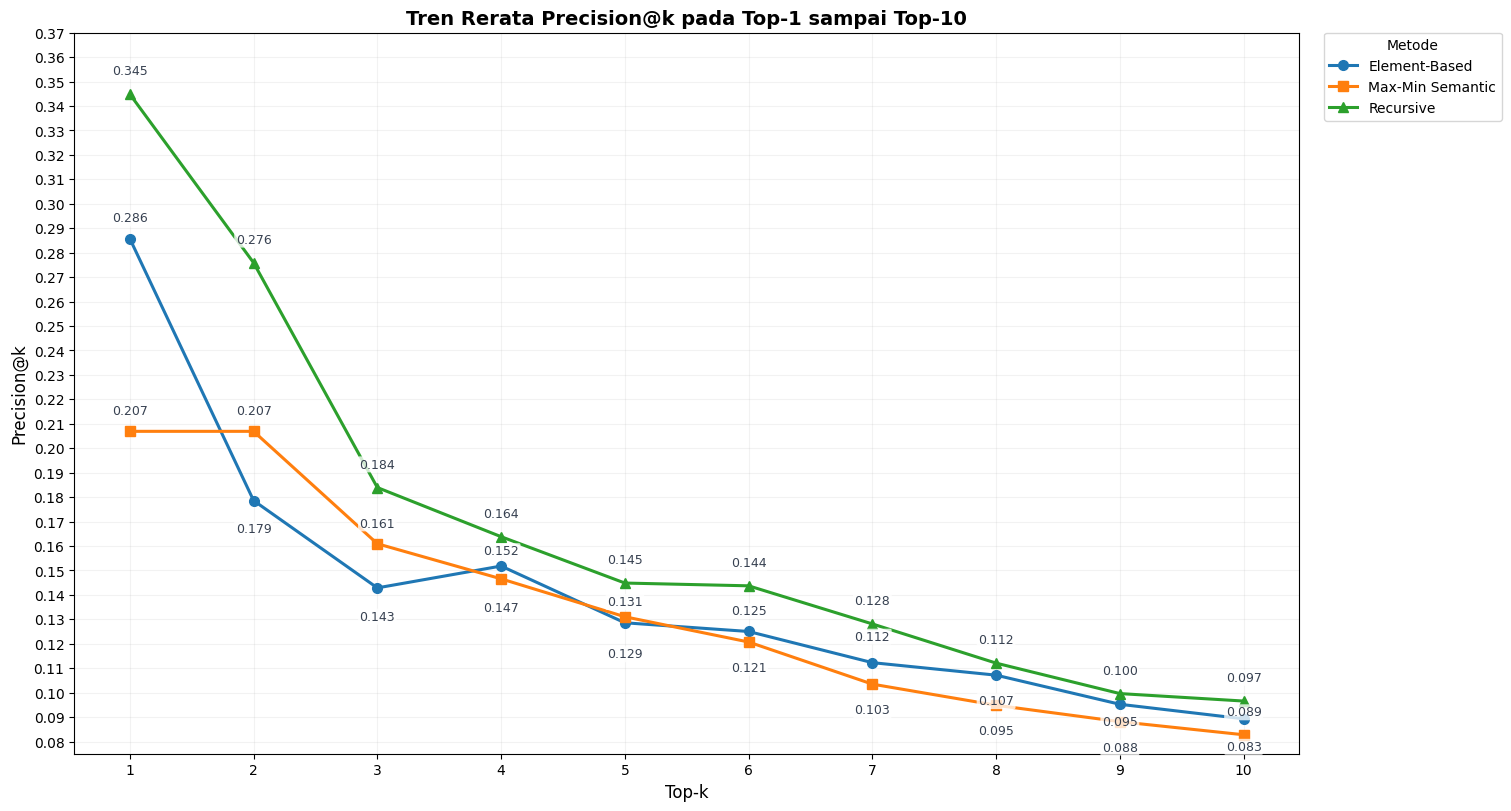

precision_at_k_top1_10.png saved


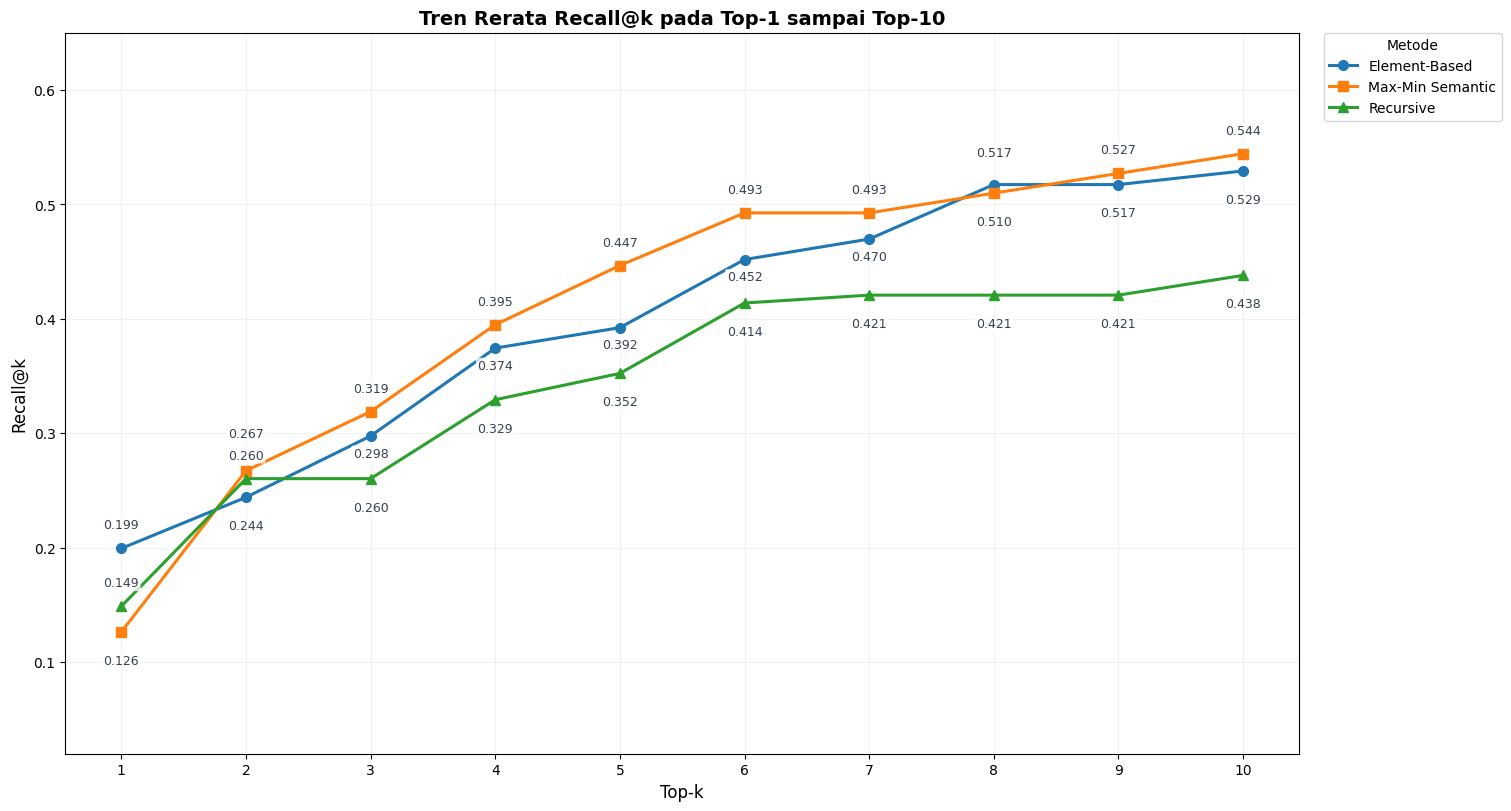

recall_at_k_top1_10.png saved


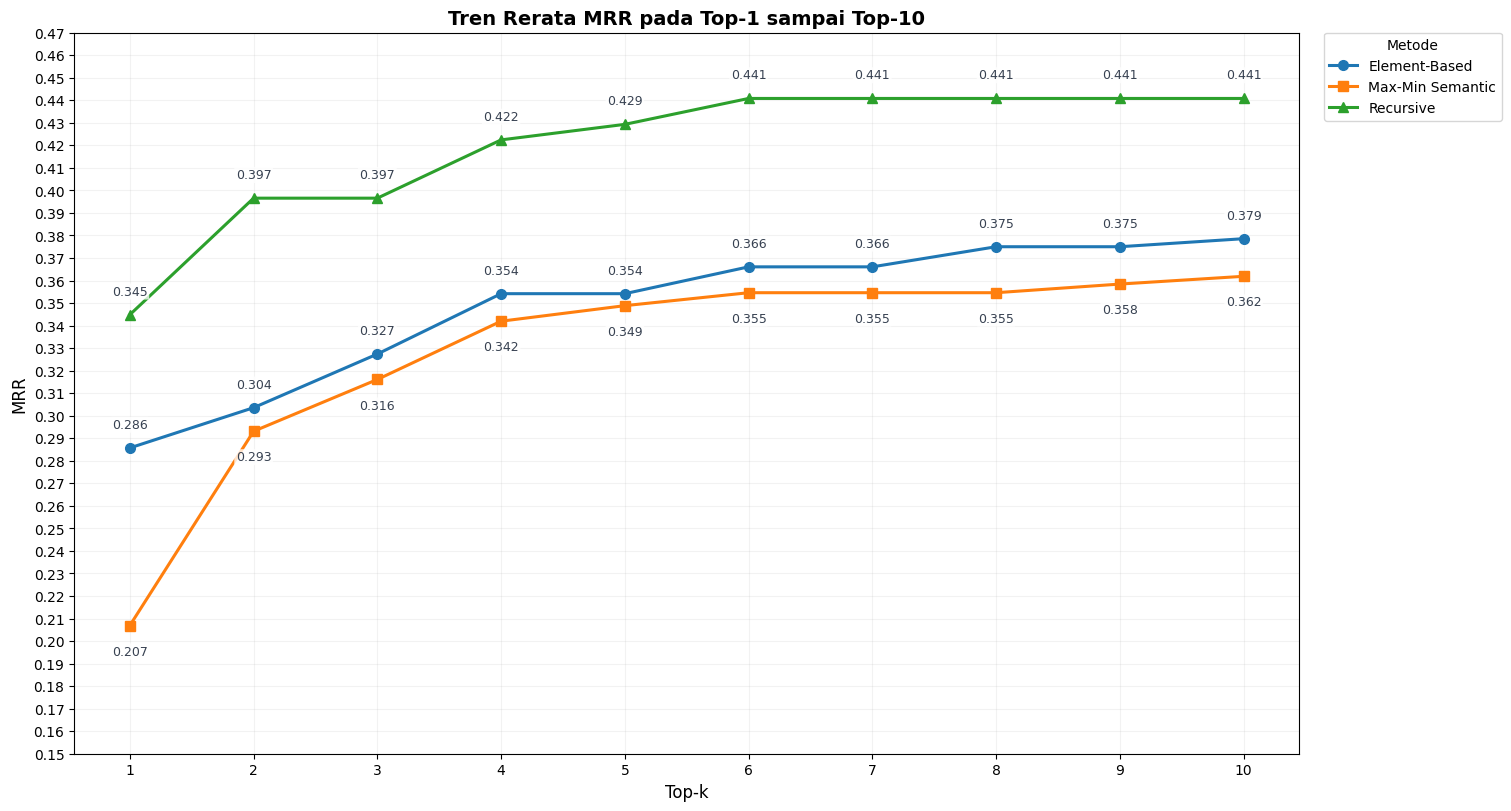

mrr_top1_10.png saved


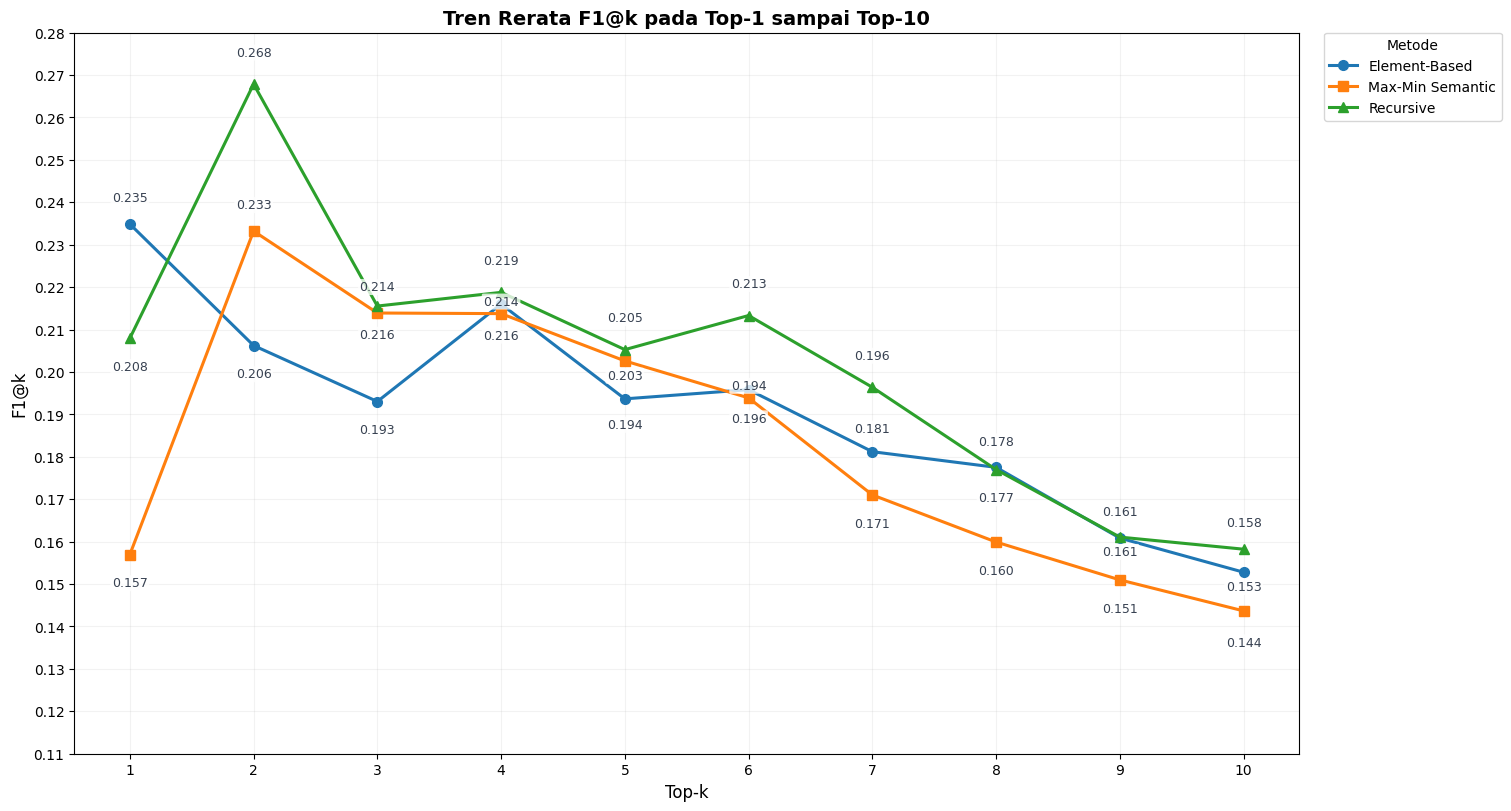

f1_at_k_top1_10.png saved


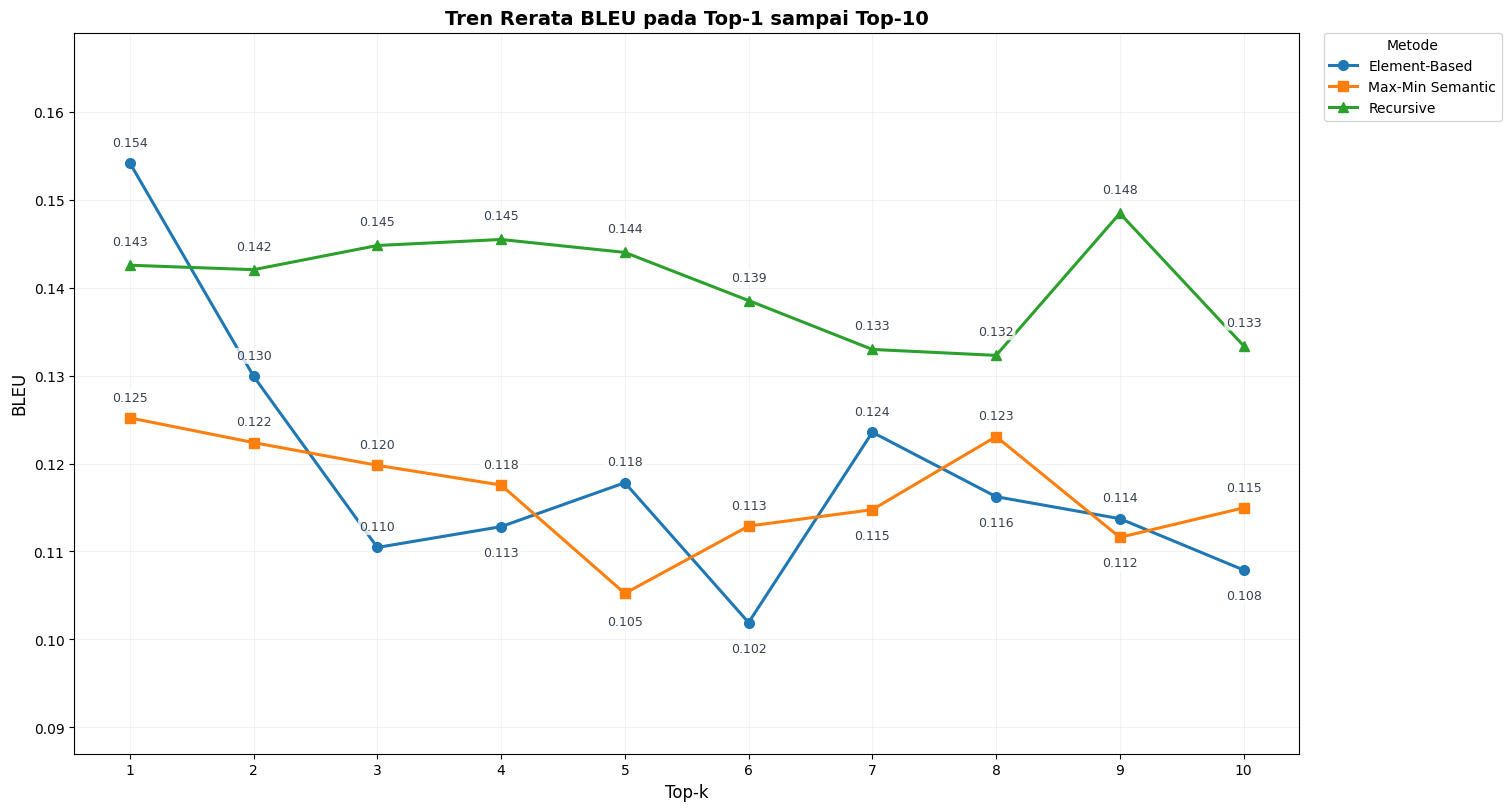

bleu_top1_10.png saved


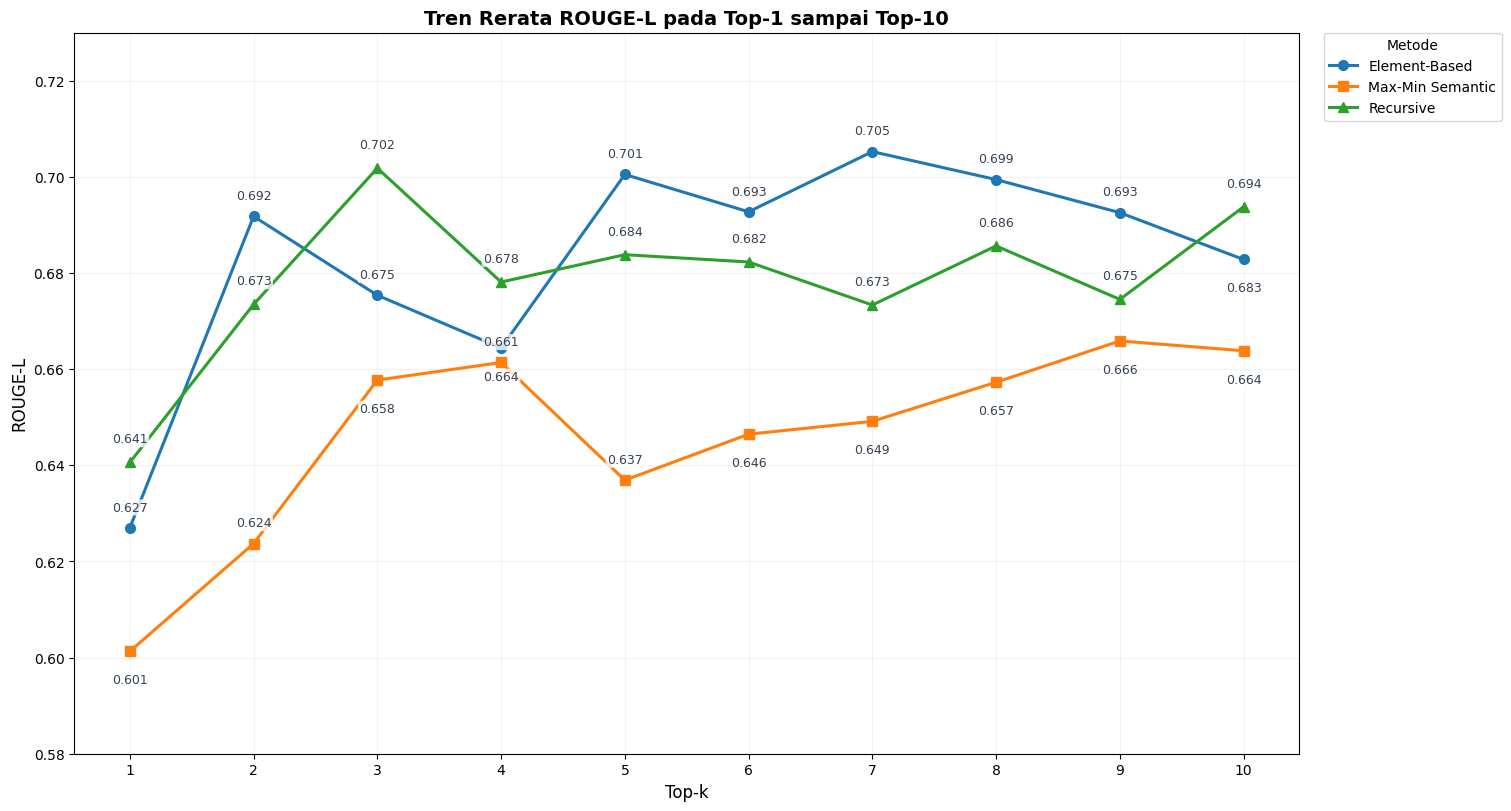

rouge_l_top1_10.png saved


In [3]:
def annotate_metric(ax, df, metric, offsets=None, default_offsets=None):
    offsets = offsets or {}
    default_offsets = default_offsets or {'Element': (0, 10), 'MaxMin': (0, -12), 'Recursive': (0, 10)}
    for _, row in df.iterrows():
        method = row['method_short']
        top_k = int(row['top_k'])
        x_offset, y_offset = offsets.get((method, top_k), default_offsets.get(method, (0, 10)))
        ax.annotate(
            f"{row[metric]:.3f}",
            (row['top_k'], row[metric]),
            textcoords='offset points',
            xytext=(x_offset, y_offset),
            ha='center',
            va='bottom' if y_offset >= 0 else 'top',
            fontsize=9,
            color='#374151',
            bbox=dict(boxstyle='round,pad=0.12', fc='white', ec='none', alpha=0.78),
        )

def plot_metric(metric, title, ylabel, filename, ylim=None, yticks=None, offsets=None, default_offsets=None):
    fig, ax = plt.subplots(figsize=(15, 8), constrained_layout=True)
    for method in ['Element', 'MaxMin', 'Recursive']:
        subset = metrics_by_k[metrics_by_k['method_short'] == method].sort_values('top_k')
        style = METHOD_STYLES[method]
        ax.plot(
            subset['top_k'], subset[metric],
            marker=style['marker'], linestyle=style['linestyle'],
            linewidth=2.2, markersize=7,
            label=METHOD_DISPLAY[method], color=METHOD_COLORS[method],
        )
    annotate_metric(ax, metrics_by_k, metric, offsets=offsets, default_offsets=default_offsets)
    ax.set_xlabel('Top-k', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(title='Metode', fontsize=10, loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)
    ax.minorticks_off()
    ax.grid(True, which='major', axis='both', alpha=0.16, linewidth=0.8)
    ax.set_xticks(range(TOPK_MIN, TOPK_MAX + 1))
    if ylim:
        ax.set_ylim(*ylim)
    else:
        y_min = float(metrics_by_k[metric].min())
        y_max = float(metrics_by_k[metric].max())
        padding = max((y_max - y_min) * 0.16, 0.01)
        ax.set_ylim(y_min - padding, y_max + padding)
    if yticks is not None:
        ax.set_yticks(yticks)
    plt.savefig(FIG_DIR / filename, dpi=300, bbox_inches='tight', pad_inches=0.3)
    plt.show()
    print(f'{filename} saved')

precision_offsets = {
    ('Element', 2): (0, -16), ('Element', 3): (0, -16), ('Element', 4): (0, 6),
    ('Element', 5): (0, -18), ('Element', 7): (0, 14), ('Element', 8): (0, -14),
    ('Element', 9): (0, -8), ('Element', 10): (0, 0),
    ('MaxMin', 4): (0, -16), ('MaxMin', 5): (0, 6), ('MaxMin', 6): (0, -14),
    ('MaxMin', 7): (0, -14), ('MaxMin', 8): (0, -14), ('MaxMin', 9): (0, -14),
    ('MaxMin', 10): (0, -4),
}
recall_offsets = {
    ('MaxMin', 1): (0, -16), ('MaxMin', 2): (0, 22), ('MaxMin', 8): (0, -16),
    ('Element', 2): (0, -16), ('Element', 3): (0, -8), ('Element', 4): (0, -8),
    ('Element', 5): (0, -8), ('Element', 6): (0, -8), ('Element', 7): (0, -8),
    ('Element', 8): (0, 18), ('Element', 9): (0, -16), ('Element', 10): (0, -16),
    ('Recursive', 3): (0, -16), ('Recursive', 4): (0, -16), ('Recursive', 5): (0, -16),
    ('Recursive', 6): (0, -16), ('Recursive', 7): (0, -16), ('Recursive', 8): (0, -16),
    ('Recursive', 9): (0, -16), ('Recursive', 10): (0, -16),
}
f1_offsets = {
    ('Element', 1): (0, 14), ('Element', 2): (0, -16), ('Element', 3): (0, -16),
    ('Element', 4): (0, -18), ('Element', 5): (0, -14), ('Element', 6): (0, -16),
    ('Element', 7): (0, 12), ('Element', 8): (0, 14), ('Element', 9): (0, 14),
    ('Element', 10): (0, -6),
    ('MaxMin', 1): (0, -16), ('MaxMin', 2): (0, 14), ('MaxMin', 3): (0, 14),
    ('MaxMin', 4): (0, 4), ('MaxMin', 5): (0, -6), ('MaxMin', 6): (0, 4),
    ('MaxMin', 7): (0, -16), ('MaxMin', 8): (0, -16), ('MaxMin', 9): (0, -16),
    ('MaxMin', 10): (0, -18),
    ('Recursive', 1): (0, -16), ('Recursive', 2): (0, 18), ('Recursive', 3): (0, -16),
    ('Recursive', 4): (0, 18), ('Recursive', 5): (0, 18), ('Recursive', 6): (0, 18),
    ('Recursive', 7): (0, 18), ('Recursive', 8): (0, -16), ('Recursive', 9): (0, -6),
    ('Recursive', 10): (0, 14),
}
bleu_offsets = {
    ('Element', 4): (0, -14), ('Element', 6): (0, -14), ('Element', 8): (0, -14),
    ('Element', 10): (0, -14), ('MaxMin', 5): (0, -16), ('MaxMin', 7): (0, -14),
    ('MaxMin', 9): (0, -14),
}
rouge_offsets = {
    ('Element', 4): (0, -16), ('Element', 10): (0, -16),
    ('MaxMin', 1): (0, -16), ('MaxMin', 3): (0, -16), ('MaxMin', 6): (0, -16),
    ('MaxMin', 7): (0, -16), ('MaxMin', 8): (0, -16), ('MaxMin', 9): (0, -16),
    ('MaxMin', 10): (0, -16),
}

plot_metric('precision_at_k', 'Tren Rerata Precision@k pada Top-1 sampai Top-10', 'Precision@k', 'precision_at_k_top1_10.png', ylim=(0.075, 0.37), yticks=np.arange(0.08, 0.371, 0.01), offsets=precision_offsets, default_offsets={'Element': (0, 10), 'MaxMin': (0, 10), 'Recursive': (0, 12)})
plot_metric('recall_at_k', 'Tren Rerata Recall@k pada Top-1 sampai Top-10', 'Recall@k', 'recall_at_k_top1_10.png', ylim=(0.02, 0.65), offsets=recall_offsets, default_offsets={'Element': (0, 12), 'MaxMin': (0, 12), 'Recursive': (0, 12)})
plot_metric('mrr', 'Tren Rerata MRR pada Top-1 sampai Top-10', 'MRR', 'mrr_top1_10.png', ylim=(0.15, 0.47), yticks=np.arange(0.15, 0.471, 0.01), default_offsets={'Element': (0, 12), 'MaxMin': (0, -14), 'Recursive': (0, 12)})
plot_metric('f1_at_k', 'Tren Rerata F1@k pada Top-1 sampai Top-10', 'F1@k', 'f1_at_k_top1_10.png', ylim=(0.11, 0.28), yticks=np.arange(0.11, 0.281, 0.01), offsets=f1_offsets)
plot_metric('bleu', 'Tren Rerata BLEU pada Top-1 sampai Top-10', 'BLEU', 'bleu_top1_10.png', ylim=(0.087, 0.169), offsets=bleu_offsets, default_offsets={'Element': (0, 10), 'MaxMin': (0, 10), 'Recursive': (0, 12)})
plot_metric('rouge_l', 'Tren Rerata ROUGE-L pada Top-1 sampai Top-10', 'ROUGE-L', 'rouge_l_top1_10.png', ylim=(0.58, 0.73), offsets=rouge_offsets, default_offsets={'Element': (0, 10), 'MaxMin': (0, 10), 'Recursive': (0, 12)})

In [4]:
metrics_by_k.to_csv(OUT_DIR / 'top1_10_metrics_by_k.csv', index=False, float_format='%.6f')
method_summary.to_csv(OUT_DIR / 'top1_10_metric_summary_by_method.csv', index=False, float_format='%.6f')
winners_df.to_csv(OUT_DIR / 'top1_10_metric_winners.csv', index=False, float_format='%.6f')
overall_average.to_csv(OUT_DIR / 'top1_10_overall_average.csv', index=False, float_format='%.6f')

qa_path = GT_DIR / 'qa_pairs_binary.json'
labels_path = GT_DIR / 'retrieval_labels_final.csv'
qa_count = len(json.loads(qa_path.read_text(encoding='utf-8'))) if qa_path.exists() else None
label_count = len(pd.read_csv(labels_path)) if labels_path.exists() else None
expected_rows = len(range(TOPK_MIN, TOPK_MAX + 1)) * len(['Element', 'MaxMin', 'Recursive'])
actual_rows = len(metrics_by_k)
complete_topk = sorted(metrics_by_k['top_k'].unique().tolist()) == list(range(TOPK_MIN, TOPK_MAX + 1))
complete_methods = set(metrics_by_k['method_short'].unique()) == {'Element', 'MaxMin', 'Recursive'}
all_row_counts_30 = bool((metrics_by_k['row_count'] == 30).all())
missing_totals = metrics_by_k[[
    'missing_precision_at_k', 'missing_recall_at_k', 'missing_mrr', 'missing_bleu', 'missing_rouge_l'
]].sum().to_dict()

analysis20_summary_path = ROOT / 'results' / 'final' / 'analysis' / 'top1_20_metric_summary_by_method.csv'
analysis20_winners_path = ROOT / 'results' / 'final' / 'analysis' / 'top1_20_metric_winners.csv'
analysis20_note = 'Artefak validasi Top-1 sampai Top-20 tidak ditemukan.'
if analysis20_summary_path.exists() and analysis20_winners_path.exists():
    w20 = pd.read_csv(analysis20_winners_path)
    w10_map = dict(zip(winners_df['metric'], winners_df['winning_method_by_average']))
    if 'winning_method_by_average' in w20.columns:
        w20_winner_col = 'winning_method_by_average'
    elif 'winner_by_top1_20_mean' in w20.columns:
        w20_winner_col = 'winner_by_top1_20_mean'
    else:
        w20_winner_col = None
    if w20_winner_col is not None:
        def normalize_method_name(name):
            return {
                'MaxMin Semantic': 'Max-Min Semantic',
                'Max-Min Semantic': 'Max-Min Semantic',
                'Element-Based': 'Element-Based',
                'Recursive': 'Recursive',
            }.get(name, name)
        w20_map = {metric: normalize_method_name(method) for metric, method in zip(w20['metric'], w20[w20_winner_col])}
        w10_map = {metric: normalize_method_name(method) for metric, method in w10_map.items()}
        same = {metric: (w10_map.get(metric) == w20_map.get(metric)) for metric in METRICS}
        consistent_metrics = [METRIC_LABELS[m] for m, ok in same.items() if ok]
        if consistent_metrics:
            analysis20_note = 'Pemenang rerata Top-1 sampai Top-10 konsisten dengan Top-1 sampai Top-20 untuk metrik: ' + ', '.join(consistent_metrics) + '.'
        else:
            analysis20_note = 'Pemenang rerata Top-1 sampai Top-10 tidak identik dengan artefak Top-1 sampai Top-20 pada metrik yang dibandingkan.'
    else:
        analysis20_note = 'Artefak Top-1 sampai Top-20 ditemukan, tetapi kolom pemenang tidak dikenali sehingga konsistensi pemenang tidak dihitung.'

audit_lines = [
    '# Audit Analisis Top-1 sampai Top-10',
    '',
    '## Sumber Data',
    f'- CSV final generation: `{GEN_DIR.relative_to(ROOT).as_posix()}/`.',
    f'- File yang dibaca: {", ".join(f"`{p}`" for p in source_files)}.',
    f'- Ground truth QA aktif: `{qa_path.relative_to(ROOT).as_posix()}` ({qa_count} QA).',
    f'- Ground truth retrieval aktif: `{labels_path.relative_to(ROOT).as_posix()}` ({label_count} anotasi relevansi chunk).',
    '',
    '## Validasi Kelengkapan',
    f'- Rentang Top-k: Top-{TOPK_MIN} sampai Top-{TOPK_MAX}.',
    f'- Jumlah baris agregat aktual: {actual_rows}.',
    f'- Jumlah baris agregat ekspektasi: {expected_rows}.',
    f'- Top-k lengkap 1 sampai 10: {"ya" if complete_topk else "tidak"}.',
    f'- Tiga metode lengkap: {"ya" if complete_methods else "tidak"}.',
    f'- Setiap kombinasi metode dan top-k berisi 30 QA: {"ya" if all_row_counts_30 else "tidak"}.',
    '',
    '## Missing Value',
]
for key, value in missing_totals.items():
    audit_lines.append(f'- {key}: {int(value)}')
audit_lines += [
    '',
    'Missing retrieval metrics berulang muncul karena beberapa kombinasi query-method tidak memiliki ground truth retrieval relevan yang dapat dievaluasi pada CSV final. Nilai ini dilaporkan, bukan dihapus diam-diam.',
    '',
    '## Catatan F1@k',
    '- F1@k dihitung ulang dari rerata Precision@k dan Recall@k pada setiap kombinasi metode dan top-k.',
    '- Kolom F1 lama pada CSV final tidak digunakan sebagai sumber utama perhitungan artefak ini.',
    '',
    '## Catatan Top-11 sampai Top-20',
    '- Bab 6 utama menggunakan Top-1 sampai Top-10.',
    '- Top-11 sampai Top-20 diposisikan sebagai validasi tambahan/lampiran, bukan dasar utama pembahasan Bab 6.',
    f'- {analysis20_note}',
]
(OUT_DIR / 'top1_10_audit_notes.md').write_text('\n'.join(audit_lines) + '\n', encoding='utf-8')

summary_round = method_summary.copy()
summary_round[METRICS] = summary_round[METRICS].round(3)
overall_round = overall_average.copy()
overall_round[METRICS + ['overall_average']] = overall_round[METRICS + ['overall_average']].round(3)
metrics_round = metrics_by_k[['top_k', 'method'] + METRICS].copy()
metrics_round[METRICS] = metrics_round[METRICS].round(3)

bab6_tables = [
    '# Tabel Siap Tempel Bab 6 - Top-1 sampai Top-10',
    '',
    '## Ringkasan Rerata Metrik per Metode',
    summary_round[['method'] + METRICS].rename(columns={'method': 'Metode', **METRIC_LABELS}).to_markdown(index=False),
    '',
    '## Metode Unggul per Metrik',
    winners_df[['metric_label', 'winning_method_by_average', 'highest_average', 'topk_winner_counts']].rename(columns={
        'metric_label': 'Metrik',
        'winning_method_by_average': 'Metode Unggul Berdasarkan Rerata',
        'highest_average': 'Rerata Tertinggi',
        'topk_winner_counts': 'Jumlah Kemenangan pada 10 Top-k',
    }).round({'Rerata Tertinggi': 3}).to_markdown(index=False),
    '',
    '## Overall Average Deskriptif',
    overall_round[['method', 'overall_average']].rename(columns={'method': 'Metode', 'overall_average': 'Overall Average'}).to_markdown(index=False),
    '',
    '## Nilai per Top-k dan Metode',
    metrics_round.rename(columns={'top_k': 'Top-k', 'method': 'Metode', **METRIC_LABELS}).to_markdown(index=False),
]
(OUT_DIR / 'bab6_tables_top1_10.md').write_text('\n\n'.join(bab6_tables) + '\n', encoding='utf-8')

def fmt(value):
    return f'{value:.3f}'
metric_winner_sentences = []
for _, row in winners_df.iterrows():
    metric_winner_sentences.append(
        f"- {row['metric_label']}: {row['winning_method_by_average']} dengan rerata {fmt(row['highest_average'])}; kemenangan per titik top-k: {row['topk_winner_counts']}."
    )

notes = [
    '# Catatan Narasi Bab 6 - Top-1 sampai Top-10',
    '',
    '## Ringkasan Angka Utama',
    'Berdasarkan evaluasi Top-1 sampai Top-10, rerata metrik per metode adalah sebagai berikut:',
    summary_round[['method'] + METRICS].rename(columns={'method': 'Metode', **METRIC_LABELS}).to_markdown(index=False),
    '',
    '## Metode Unggul per Metrik',
    *metric_winner_sentences,
    '',
    '## Karakter Element-Based Chunking',
    f"Element-Based menunjukkan kecenderungan kuat pada ROUGE-L dengan rerata {fmt(method_summary.loc[method_summary['method'] == 'Element-Based', 'rouge_l'].iloc[0])}. Pada konfigurasi eksperimen ini, metode ini juga memiliki rerata Recall@k {fmt(method_summary.loc[method_summary['method'] == 'Element-Based', 'recall_at_k'].iloc[0])}, tetapi tidak menjadi yang tertinggi dibanding Max-Min Semantic. Interpretasi yang dapat dipertanggungjawabkan: Element-Based cenderung menghasilkan jawaban dengan urutan informasi yang lebih dekat ke referensi, tetapi bukan yang paling kuat pada ketepatan retrieval atau posisi chunk relevan pertama.",
    '',
    '## Karakter Max-Min Semantic Chunking',
    f"Max-Min Semantic menunjukkan kecenderungan unggul pada Recall@k dengan rerata {fmt(method_summary.loc[method_summary['method'] == 'Max-Min Semantic', 'recall_at_k'].iloc[0])}. Ini berarti pada Top-1 sampai Top-10 metode ini lebih mampu menjangkau chunk relevan. Namun rerata Precision@k {fmt(method_summary.loc[method_summary['method'] == 'Max-Min Semantic', 'precision_at_k'].iloc[0])}, MRR {fmt(method_summary.loc[method_summary['method'] == 'Max-Min Semantic', 'mrr'].iloc[0])}, dan F1@k {fmt(method_summary.loc[method_summary['method'] == 'Max-Min Semantic', 'f1_at_k'].iloc[0])} tidak menjadi yang tertinggi. Jadi klaim yang aman: metode ini cenderung kuat pada cakupan retrieval, bukan pada ketepatan atau ranking awal.",
    '',
    '## Karakter Recursive Chunking',
    f"Recursive menunjukkan kecenderungan unggul pada Precision@k ({fmt(method_summary.loc[method_summary['method'] == 'Recursive', 'precision_at_k'].iloc[0])}), MRR ({fmt(method_summary.loc[method_summary['method'] == 'Recursive', 'mrr'].iloc[0])}), F1@k ({fmt(method_summary.loc[method_summary['method'] == 'Recursive', 'f1_at_k'].iloc[0])}), dan BLEU ({fmt(method_summary.loc[method_summary['method'] == 'Recursive', 'bleu'].iloc[0])}). Pada konfigurasi eksperimen ini, karakter utamanya adalah lebih presisi dan lebih stabil menempatkan chunk relevan awal, tetapi Recall@k dan ROUGE-L tidak menjadi yang tertinggi.",
    '',
    '## Analisis Retrieval',
    'Precision@k, MRR, dan F1@k lebih condong ke Recursive, sedangkan Recall@k lebih condong ke Max-Min Semantic. Ini menunjukkan trade-off yang jelas: Max-Min Semantic menjangkau lebih banyak chunk relevan, sementara Recursive lebih kuat pada ketepatan dan posisi relevansi awal. Klaim ini bersifat deskriptif karena tidak ada uji statistik.',
    '',
    '## Analisis Generation',
    'BLEU lebih tinggi pada Recursive, sedangkan ROUGE-L lebih tinggi pada Element-Based. Karena BLEU dan ROUGE-L mengukur aspek berbeda, hasil ini tidak boleh disederhanakan menjadi satu metode paling baik secara mutlak. Data hanya mendukung bahwa Recursive lebih kuat pada kemiripan leksikal, sedangkan Element-Based lebih kuat pada cakupan urutan informasi referensi.',
    '',
    '## Implikasi terhadap Rumusan Masalah',
    '- Rumusan masalah 1: Perbedaan metode chunking menghasilkan karakter retrieval yang berbeda pada Top-1 sampai Top-10.',
    '- Rumusan masalah 2: Pengaruh terhadap generation tidak identik dengan retrieval; BLEU dan ROUGE-L memberi sinyal yang berbeda.',
    '- Rumusan masalah 3: Perbandingan akhir perlu menekankan trade-off, bukan menyatakan satu metode terbaik mutlak.',
    '',
    '## Catatan Keterbatasan',
    '- Dataset evaluasi berisi 30 QA, sehingga generalisasi ke korpus lain belum bisa dipastikan.',
    '- Tidak ada uji statistik; klaim inferensial tidak dibuat.',
    '- Missing retrieval metrics dilaporkan dalam audit dan tidak dihapus diam-diam.',
    '- Top-11 sampai Top-20 hanya validasi tambahan/lampiran; basis utama Bab 6 adalah Top-1 sampai Top-10.',
    '',
    '## File Dasar Analisis',
    f"- `{(OUT_DIR / 'top1_10_metrics_by_k.csv').relative_to(ROOT).as_posix()}`",
    f"- `{(OUT_DIR / 'top1_10_metric_summary_by_method.csv').relative_to(ROOT).as_posix()}`",
    f"- `{(OUT_DIR / 'top1_10_metric_winners.csv').relative_to(ROOT).as_posix()}`",
    f"- `{(OUT_DIR / 'top1_10_audit_notes.md').relative_to(ROOT).as_posix()}`",
]
(OUT_DIR / 'bab6_data_notes_top1_10.md').write_text('\n'.join(notes) + '\n', encoding='utf-8')

print('Output written to:', OUT_DIR)
print('Figures written to:', FIG_DIR)

Output written to: D:\My Files\Kuliah\SKRIPSI\rag-skripsi\results\final\analysis10
Figures written to: D:\My Files\Kuliah\SKRIPSI\rag-skripsi\results\final\analysis10\figures
